In [1]:
#%pip install scikit-learn
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.preprocessing import StandardScaler


In [3]:
data_mat = pd.read_csv("../BDD_initial/student-mat.csv", sep=",", index_col=0)
data_mat.head()
data_por = pd.read_csv("../BDD_initial/student-por.csv", sep=",", index_col=0)
data_por.head()

,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
school,,,,,,,,,,,,,,,,,,,,,
GP,F,18,U,GT3,A,4,4,at_home,teacher,course,...,4,3,4,1,1,3,4,0,11,11
GP,F,17,U,GT3,T,1,1,at_home,other,course,...,5,3,3,1,1,3,2,9,11,11
GP,F,15,U,LE3,T,1,1,at_home,other,other,...,4,3,2,2,3,3,6,12,13,12
GP,F,15,U,GT3,T,4,2,health,services,home,...,3,2,2,1,1,5,0,14,14,14
GP,F,16,U,GT3,T,3,3,other,other,home,...,4,3,2,1,2,5,0,11,13,13


In [4]:
merge_cols = [col for col in data_mat.columns if col not in ["G1", "G2", "G3", "absences"]]

data=pd.merge(data_mat, data_por, on=merge_cols, how="outer", suffixes=("_mat", "_por"))
data.head()


,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,...,Walc,health,absences_mat,G1_mat,G2_mat,G3_mat,absences_por,G1_por,G2_por,G3_por
0,F,15,R,GT3,T,1,1,at_home,at_home,course,...,2,2,NaN,NaN,NaN,NaN,0.0,13.0,14.0,14.0
1,F,15,R,GT3,T,1,1,at_home,other,home,...,1,2,NaN,NaN,NaN,NaN,1.0,11.0,10.0,11.0
2,F,15,R,GT3,T,1,1,at_home,other,home,...,1,1,NaN,NaN,NaN,NaN,4.0,13.0,13.0,13.0
3,F,15,R,GT3,T,1,1,at_home,other,home,...,1,1,2.0,7.0,10.0,10.0,NaN,NaN,NaN,NaN
4,F,15,R,GT3,T,1,1,at_home,services,other,...,1,2,NaN,NaN,NaN,NaN,6.0,10.0,10.0,10.0


In [5]:
print(data.columns)


Index(['sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob',
       'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures',
       'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher',
       'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc',
       'health', 'absences_mat', 'G1_mat', 'G2_mat', 'G3_mat', 'absences_por',
       'G1_por', 'G2_por', 'G3_por'],
      dtype='str')


In [6]:
label = ['course', 'other', 'home', 'reputation']
prop=[data_mat[(data_mat["reason"] == name)]["studytime"].count()/len(data_mat) for name in label]

label_por = ['course', 'other', 'home', 'reputation']
prop_por=[data_por[(data_por["reason"] == name)]["studytime"].count()/len(data_por) for name in label]



Ces graphiques représentent les différentes raisons d'intégration des études avec 'home' signifiant la proximité de l'établissement au domicile.

On remarque qu'une majorité des étudiants choississent leurs études en fonction des cours dispensés, suivis de facon équivalente par la réputation et la proximité.

On peut alors se demander si cela impacte leurs sérieux, résultats et consommations d'alcool par la suite. 


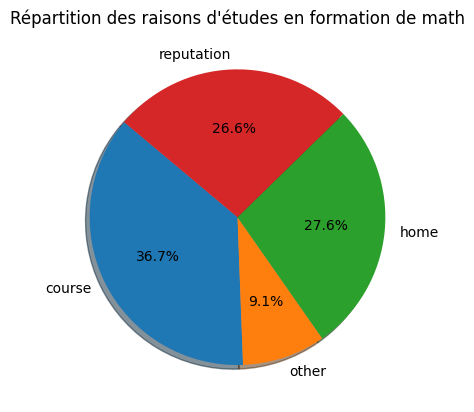

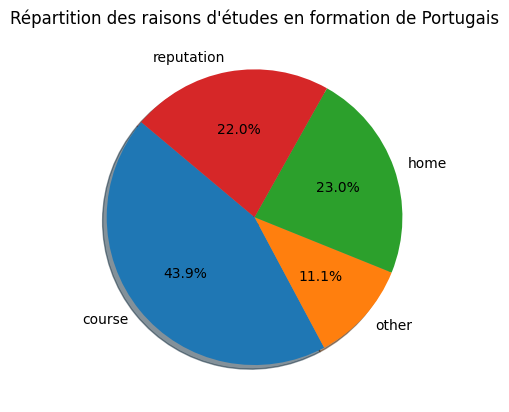

In [7]:
plt.pie(prop, labels=label,autopct='%1.1f%%', shadow=True, startangle=140)
plt.title("Répartition des raisons d'études en formation de math")
plt.show()

plt.pie(prop_por, labels=label_por,autopct='%1.1f%%', shadow=True, startangle=140)
plt.title("Répartition des raisons d'études en formation de Portugais")
plt.show()




In [8]:
meanG = (data_mat["G3"]+data_mat["G2"]+data_mat["G1"])/3
meanG
data_mat["meanG"] = meanG
data_mat.head()

meanG = (data_por["G3"]+data_por["G2"]+data_por["G1"])/3
meanG
data_por["meanG"] = meanG
data_por.head()
#Moyennes des notes dans l'année. 

,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,...,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3,meanG
school,,,,,,,,,,,,,,,,,,,,,
GP,F,18,U,GT3,A,4,4,at_home,teacher,course,...,3,4,1,1,3,4,0,11,11,7.333333
GP,F,17,U,GT3,T,1,1,at_home,other,course,...,3,3,1,1,3,2,9,11,11,10.333333
GP,F,15,U,LE3,T,1,1,at_home,other,other,...,3,2,2,3,3,6,12,13,12,12.333333
GP,F,15,U,GT3,T,4,2,health,services,home,...,2,2,1,1,5,0,14,14,14,14.000000
GP,F,16,U,GT3,T,3,3,other,other,home,...,3,2,1,2,5,0,11,13,13,12.333333


Sur le premier graphique, on remarque une évolution notoire des moyennes des élèves en fonction de leur temps d'étude principalement pour ceux ayant choisie leurs écoles pour leurs proximités, leur réputations ou d'autres raisons. 

Cependant, les élèves ayant choisie leurs écoles pour les cours n'ont pas d'évolution en fonction de leurs temps d'étude mais une baisse !

Il en va de même pour les élèves de portugais (second graphique) sauf pour la 4 heures d'étude dans laquelle la baisse des notes est présente qu'importe leurs raisons d'étude.


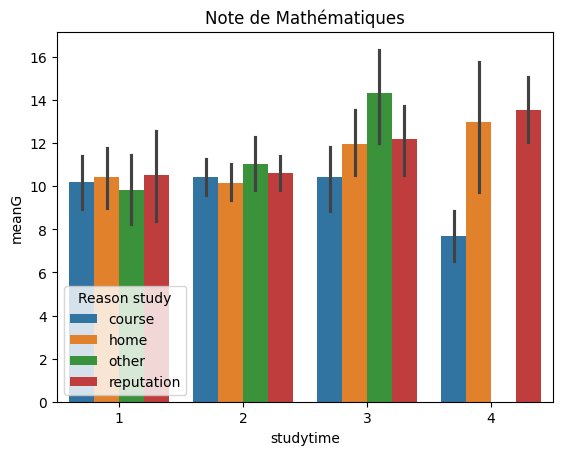

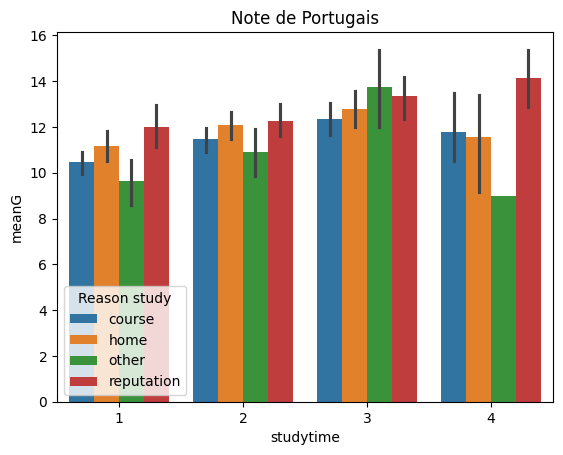

In [9]:
fig = plt.figure()
ax = sns.barplot(data_mat, x="studytime", y="meanG", estimator=np.mean, hue = "reason")
ax.title.set_text("Note de Mathématiques")
ax.legend(loc="lower left", title="Reason study")

fig = plt.figure()
ax = sns.barplot(data_por, x="studytime", y="meanG", estimator=np.mean, hue = "reason")
ax.title.set_text("Note de Portugais")

ax.legend(loc="lower left", title="Reason study")


Ce graphique permet de nuancer les précendants en représentant la répartition non égalitaire des raisons d'études parmis les étudiants.

En effet, ceux travaillant 2h par semaines sont les plus majoritaires et ceux travaillant 3 et 4h sont beaucoup moins présents.

On peut également remarquer la baisse du nombre d'étudiants consommant de plus en plus d'alcool. 


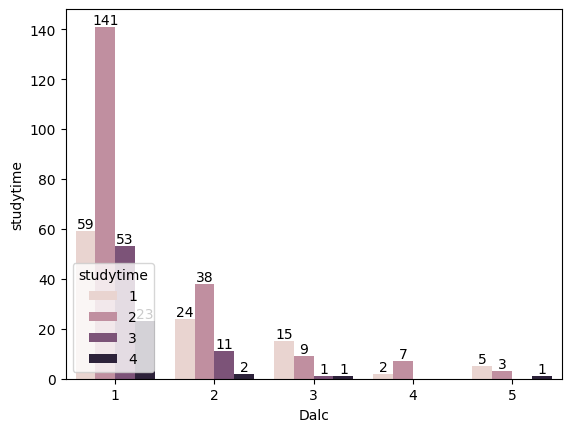

In [17]:
fig = plt.figure()

ax = sns.barplot(data=data_mat, x="Dalc", y="studytime", estimator=np.count_nonzero, hue="studytime")
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f')

ax.legend(loc="lower left", title="studytime")


Ce barplot nous permet de constater que les élèves plus agé réussissent de moins en moins plus ils consomment de l'alcool, cependant le second graphique nous montre que nous disposons de très peu d'élèves ayant 20 ans ou plus, ce qui rend toutes analyses biaisées.


C:\Users\sidsm\AppData\Local\Temp\ipykernel_16736\2252888003.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc="upper right", title="Nombre d'étudiants")


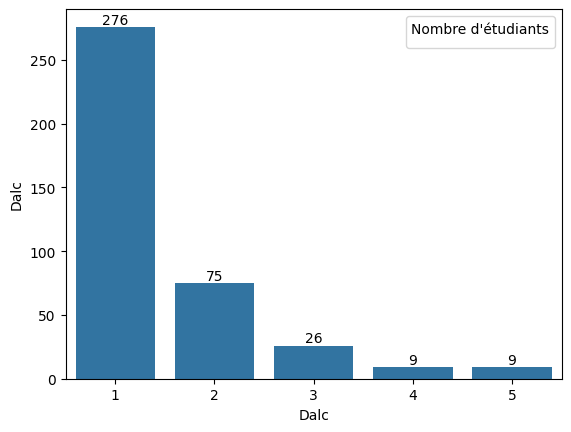

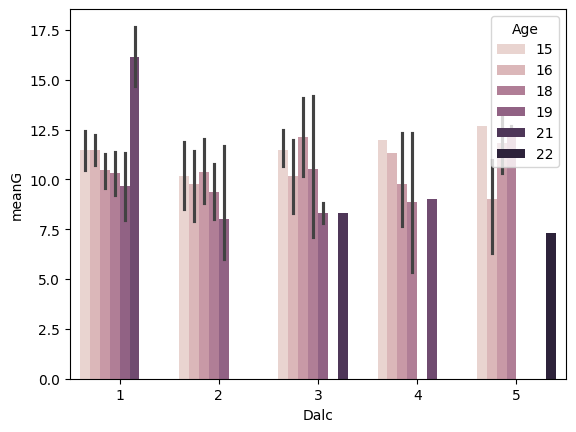

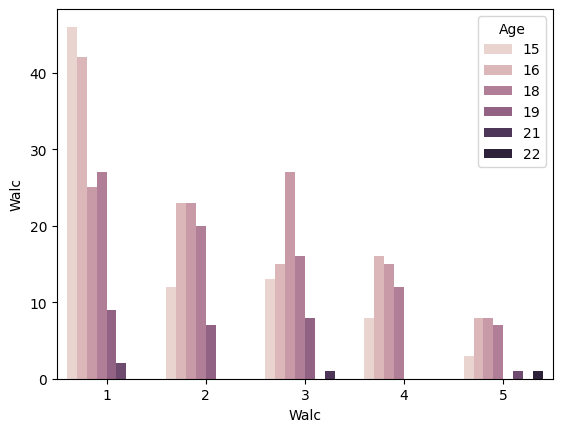

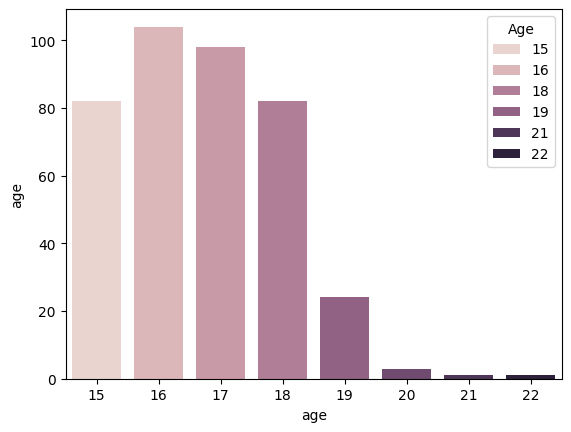

In [15]:
fig = plt.figure()

ax = sns.barplot(data_mat, x="Dalc", y="Dalc", estimator=np.count_nonzero)
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f')
ax.legend(loc="upper right", title="Nombre d'étudiants")

fig = plt.figure()

ax = sns.barplot(data_mat, x="Dalc", y="meanG", estimator=np.mean, hue = "age")

ax.legend(loc="upper right", title="Age")

fig = plt.figure()

ax = sns.barplot(data_mat, x="Walc", y="Walc", estimator=np.count_nonzero, hue = "age")

ax.legend(loc="upper right", title="Age")



fig = plt.figure()

ax = sns.barplot(data_mat, x="age", y="age", estimator=np.count_nonzero, hue = "age")

ax.legend(loc="upper right", title="Age")



C:\Users\sidsm\AppData\Local\Temp\ipykernel_16736\3102710517.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups.values, labels=groups.index)


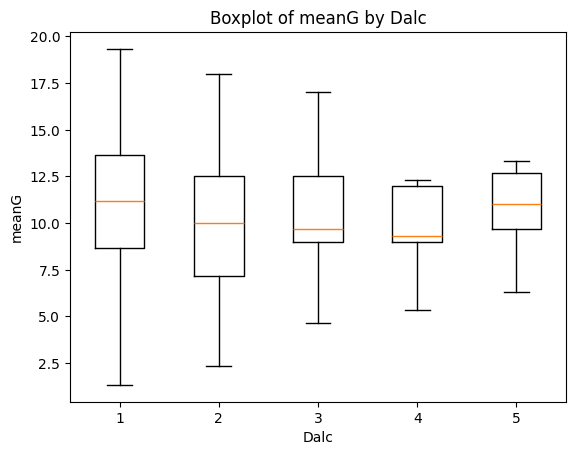

In [16]:
groups = data_mat.groupby('Dalc')['meanG'].apply(list)
plt.boxplot(groups.values, labels=groups.index)
plt.xlabel('Dalc')
plt.ylabel('meanG')
plt.title('Boxplot of meanG by Dalc')
plt.show()

In [ ]:
categorical_cols = data_mat.drop(["Dalc","Walc"],axis=1).columns
data_mat2 = data_mat.drop(["Dalc","Walc"],axis=1)
categorical_cols

Index(['sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob',
       'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures',
       'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher',
       'internet', 'romantic', 'famrel', 'freetime', 'goout', 'health',
       'absences', 'G1', 'G2', 'G3', 'meanG'],
      dtype='str')

In [ ]:
from sklearn.preprocessing import LabelEncoder

label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    data_mat2[col] = le.fit_transform(data_mat2[col])
    label_encoders[col] = le
    print(f"  {col}: {dict(zip(le.classes_, le.transform(le.classes_)))}")

print("\nAperçu après encodage :")
data_mat2.head()

  sex: {'F': np.int64(0), 'M': np.int64(1)}
  age: {np.int64(15): np.int64(0), np.int64(16): np.int64(1), np.int64(17): np.int64(2), np.int64(18): np.int64(3), np.int64(19): np.int64(4), np.int64(20): np.int64(5), np.int64(21): np.int64(6), np.int64(22): np.int64(7)}
  address: {'R': np.int64(0), 'U': np.int64(1)}
  famsize: {'GT3': np.int64(0), 'LE3': np.int64(1)}
  Pstatus: {'A': np.int64(0), 'T': np.int64(1)}
  Medu: {np.int64(0): np.int64(0), np.int64(1): np.int64(1), np.int64(2): np.int64(2), np.int64(3): np.int64(3), np.int64(4): np.int64(4)}
  Fedu: {np.int64(0): np.int64(0), np.int64(1): np.int64(1), np.int64(2): np.int64(2), np.int64(3): np.int64(3), np.int64(4): np.int64(4)}
  Mjob: {'at_home': np.int64(0), 'health': np.int64(1), 'other': np.int64(2), 'services': np.int64(3), 'teacher': np.int64(4)}
  Fjob: {'at_home': np.int64(0), 'health': np.int64(1), 'other': np.int64(2), 'services': np.int64(3), 'teacher': np.int64(4)}
  reason: {'course': np.int64(0), 'home': np.int64(1

,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,...,romantic,famrel,freetime,goout,health,absences,G1,G2,G3,meanG
school,,,,,,,,,,,,,,,,,,,,,
GP,0,3,1,0,0,4,4,0,4,0,...,0,3,2,3,2,6,2,3,3,13
GP,0,2,1,0,1,1,1,0,2,0,...,0,4,2,2,2,4,2,2,3,12
GP,0,0,1,1,1,1,1,0,2,2,...,0,3,2,1,2,10,4,5,7,21
GP,0,0,1,0,1,4,2,1,3,1,...,1,2,1,1,4,2,12,11,12,40
GP,0,1,1,0,1,3,3,2,2,1,...,0,3,2,1,4,4,3,7,7,22


<Axes: >

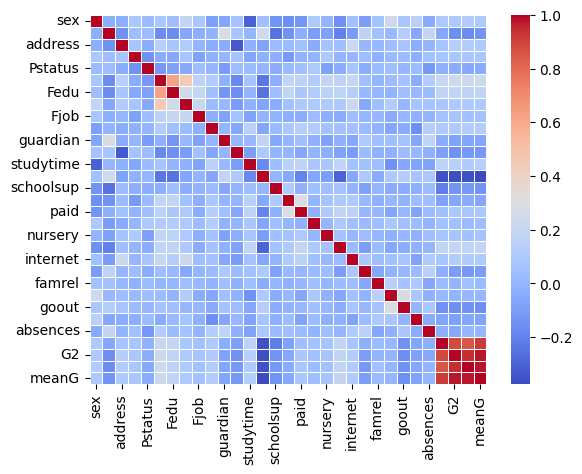

In [ ]:


sns.heatmap(data_mat2.corr(), annot=False, cmap="coolwarm", linewidths=0.5)




<Axes: >

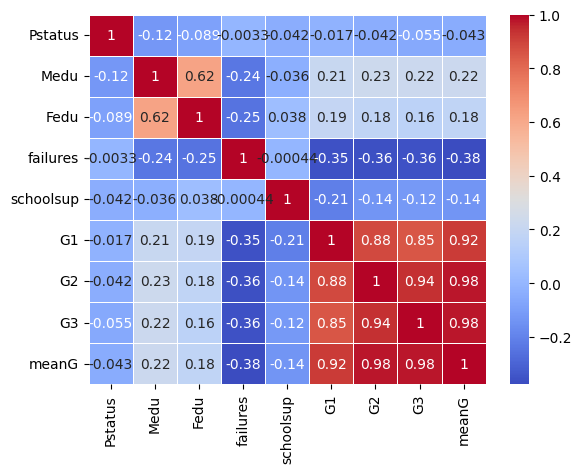

In [ ]:
data3=data_mat2[["Pstatus","Medu","Fedu","failures","schoolsup","G1","G2","G3","meanG"]]
sns.heatmap(data3.corr(), annot=True, cmap="coolwarm", linewidths=0.5)
